In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market import Market

In [2]:
from joblib import dump, load

market = load(project_root / "results/market_simulation_final.joblib")

In [4]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [5]:
scenario, r_m, last_r, last_vol, lasts = make_scenario(100, "weekly", market, return_last=True)

In [366]:
N = 20 # n_assets
T = 10 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

trade_cost = 0.003

In [7]:
scenarios = generate_scenarios(K, T, N, 'weekly', market)

## MPC

In [474]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [475]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.2, trade=trade_cost, risk_type='semi_variance', cvar_alpha=0.90)

In [476]:
controller.is_QP_and_DPP()

(True, True)

In [15]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner', leave=False):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [477]:
from src.utils import FREQ_COEFF
MAGIC_NUMBER = 20

In [486]:
from tqdm.notebook import tqdm
import math
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):
        # NOTE: lasts are always daily for market, and market return is too
        #actual_traj, market_return, last_r_m, last_vol, lasts =\
        #    make_scenario(n_steps, freq, market, return_last=True)

        extra = math.ceil(MAGIC_NUMBER / FREQ_COEFF[freq])
        actual_traj, market_return, context = make_scenario(n_steps + extra, freq, market, return_full_daily=True, return_sectors=True)

        # first were generated for context - leave one extra for previous index
        actual_traj = actual_traj.iloc[-(n_steps+1):] 
        market_return = market_return.iloc[-(n_steps+1):]

        # reindex and transpose sectors
        full_date_index = context['market'].index
        context['sectors'] = pd.DataFrame(context['sectors'].T, index=full_date_index)

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}', leave=False):

            next_date = actual_traj.index[step+1]
            current_date = actual_traj.index[step]

            current_loc = full_date_index.get_loc(current_date)

            start, end = full_date_index[current_loc - MAGIC_NUMBER + 1], full_date_index[current_loc] # loc is exclusive

            scenarios = generate_scenarios(K ,T, N, freq, market, burn=0,
                                           initial_market_returns=context['market'].loc[start:end],
                                           initial_market_vols=context['market_vol'].loc[start:end], 
                                           initial_sector_returns=context['sectors'].loc[start:end].to_numpy())
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve(solver='CLARABEL')
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.loc[next_date]])

            MPC_sim.append(x_next)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return[1:]])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.iloc[1:].T, trading_cost=trade_cost)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/52 [00:00<?, ?it/s]

...

simulation 46:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 47:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 48:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 49:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 50:   0%|          | 0/52 [00:00<?, ?it/s]

## Results

In [487]:
from joblib import dump
dump(MPC_sims, project_root / "results/dyn_beta/MPC_sims_cvar.joblib")
dump(market_sims, project_root / "results/dyn_beta/market_sims_cvar.joblib")
dump(eq_sims, project_root / "results/dyn_beta/eq_sims_cvar.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\dyn_beta\\eq_sims_cvar.joblib']

In [488]:
from joblib import load
MPC_sims = load(project_root / "results/dyn_beta/MPC_sims_cvar.joblib")
market_sims = load(project_root / "results/dyn_beta/market_sims_cvar.joblib")
eq_sims = load(project_root / "results/dyn_beta/eq_sims_cvar.joblib")

In [489]:
df = pd.DataFrame(MPC_sims[4])
eq_df = pd.DataFrame(eq_sims[4])

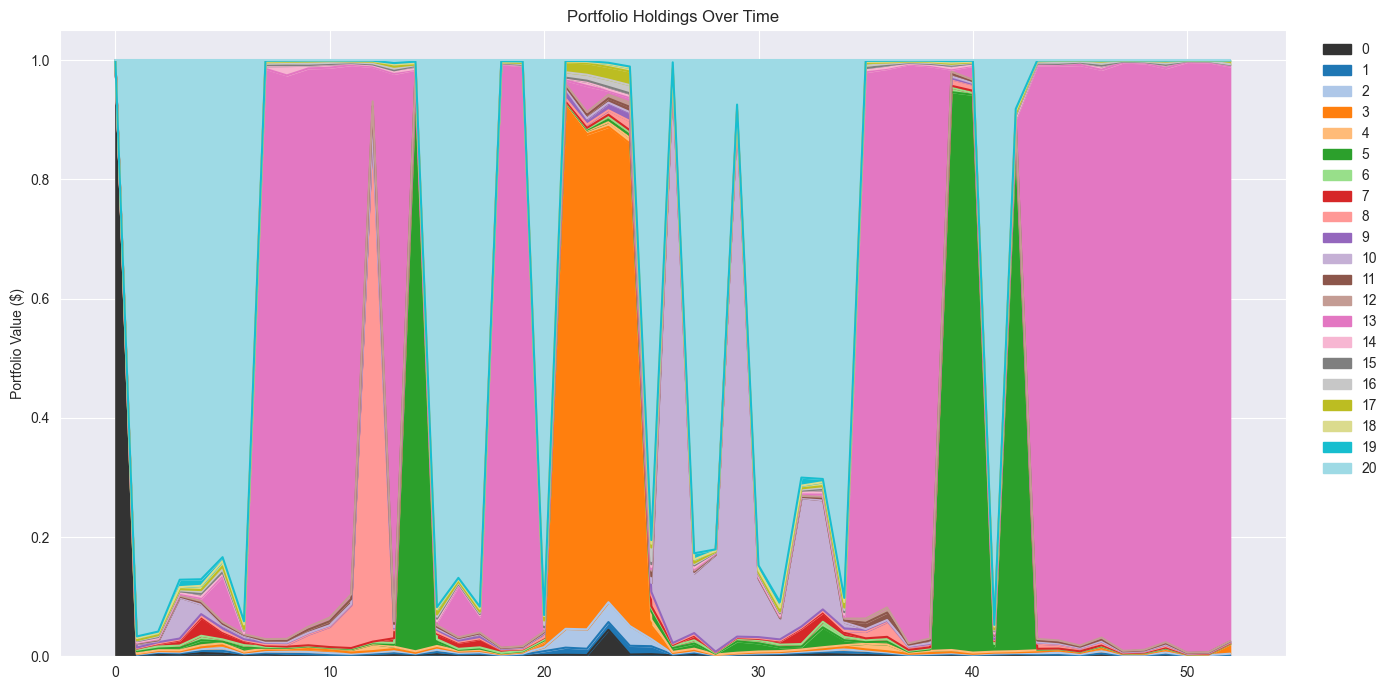

In [490]:
import matplotlib.pyplot as plt
import seaborn as sns

# all except cash
asset_colors = sns.color_palette("tab20", market.n_assets)

# add cash color at the end
colors =  [(0.2, 0.2, 0.2)] + asset_colors

weights = df.div(df.sum(axis=1), axis=0)
weights[weights < 0] = 0

ax = weights.plot.area(
    figsize=(14, 7),
    #cmap=cmap
    color=colors
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Portfolio Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [496]:
sector_holdings = pd.DataFrame()

sector_holdings['cash'] = df[0]
df_ = df.drop(0, axis=1)

for sector in range(market.n_sectors):
    sector_holdings[sector] = df_.T.iloc[market.sectors == sector].sum(axis=0)

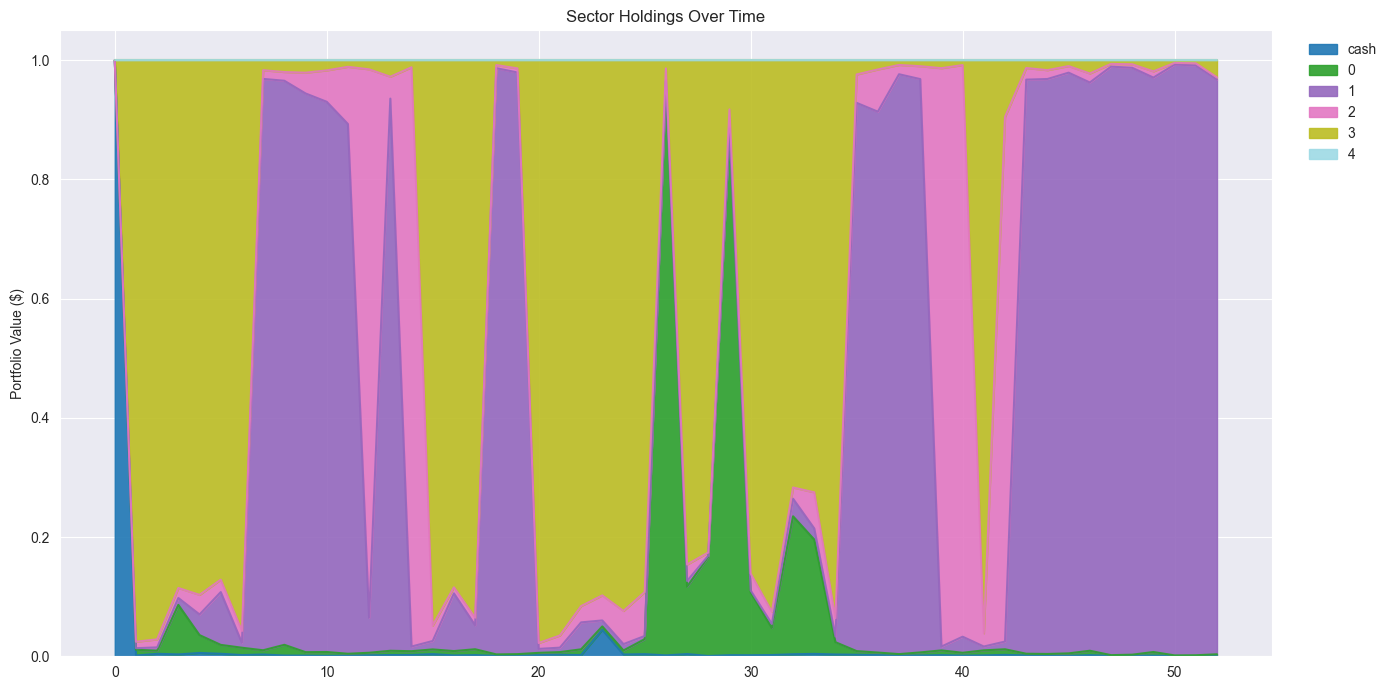

In [497]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap("tab20")

sector_weights = sector_holdings.div(df.sum(axis=1), axis=0)
sector_weights[sector_weights < 0] = 0

ax = sector_weights.plot.area(
    figsize=(14, 7),
    cmap=cmap,
    alpha=0.9
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Sector Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [498]:
market.summary()

,alpha,beta,idio vols,sector,sector_coeffs,sector_vols,vol_premium
0,0.000075,0.378626,0.007238,3,0.351078,0.009845,-1.122342
1,0.000238,0.403850,0.007925,3,0.366715,0.009845,-1.430229
2,0.000223,0.480959,0.009377,3,0.422191,0.009845,-1.678830
3,0.000184,0.326232,0.006609,2,0.398007,0.007329,-1.152486
4,0.000006,0.504739,0.009930,2,0.612164,0.007329,1.773490
5,0.000027,0.358018,0.006769,2,0.397073,0.007329,1.181887
6,-0.000053,0.445212,0.008539,1,0.359145,0.010050,1.456852
7,0.000057,0.578288,0.010992,2,0.648493,0.007329,-1.844355
8,0.000164,0.337301,0.006568,3,0.344289,0.009845,-1.056401
9,-0.000239,0.698462,0.013642,0,0.612759,0.010299,2.275456


In [499]:
rm = pd.Series(market_sims[4])

In [500]:
rm = rm.pct_change()
rm = rm - rm.mean()
m_volatility = (rm**2).ewm(span=20, adjust=False).mean()
m_fast = (rm**2).ewm(span=2, adjust=False).mean()

<Axes: >

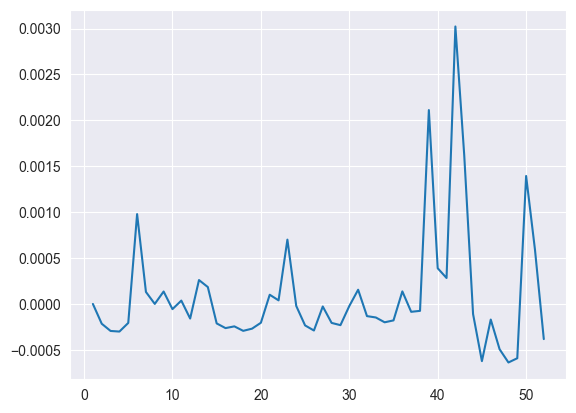

In [501]:
(m_fast - m_volatility).plot()

In [502]:
mm = pd.DataFrame(market_sims[4])

In [503]:
market_sims.std(axis=1)

array([ 8.16140903,  7.50359647,  4.2100711 ,  6.99362105,  8.01753196,
        4.6289152 ,  3.68226564,  7.98297076,  6.23365493,  5.11084754,
        8.37097809,  7.27563092, 11.83592284,  4.05872601,  4.11019139,
        9.18857245, 11.01381242,  4.80959876,  4.41561338, 11.55930518,
        8.08600851,  2.50000344, 13.42891669,  9.35935412,  3.46752428,
        5.65441802,  4.31589198,  4.70548368,  6.54968659,  4.63495219,
       15.51635084,  4.0871012 , 11.77545247,  7.63830683, 13.08924715,
       10.49611696,  3.18095067, 11.43468863,  4.05782134,  6.48740771,
       11.67445393,  4.30826672,  3.64185438,  4.70768252,  6.14690118,
        5.24518185, 12.34889872,  8.74979524,  7.30430557,  9.08069015])

<Axes: >

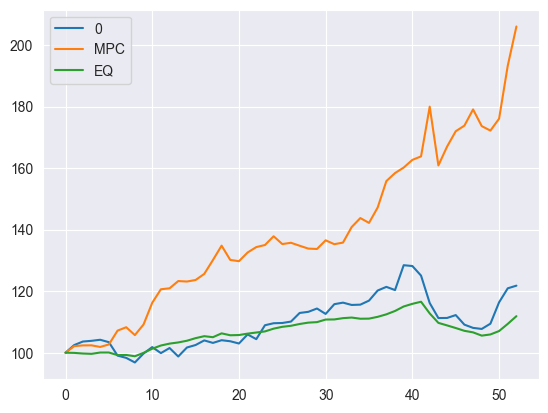

In [504]:
mm.plot(label='market', legend=True)
df.sum(axis=1).plot(label='MPC', legend=True)
eq_df.sum(axis=1).plot(label='EQ', legend=True)


In [505]:
w_ = weights.T.loc[1:]

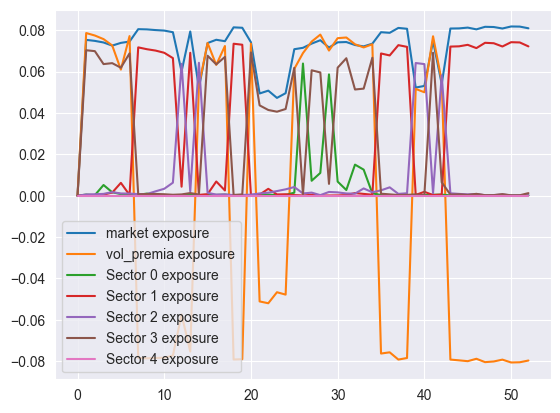

In [506]:
# Plot exposures to factors from coefficients

(weights @ np.hstack([0, market.betas]) / market.betas.sum()).plot(label = 'market exposure', legend=True)
(weights @ np.hstack([0, market.vol_premia]) / np.linalg.norm(market.vol_premia, 1)).plot(label = 'vol_premia exposure', legend=True)

sector_exps = []
sector_scale = market.sector_coeffs.sum()

for sector in range(market.n_sectors):
    sector_mask = market.sectors == sector
    sector_exp = market.sector_coeffs[sector_mask] @ w_.iloc[sector_mask]
    sector_exps.append(sector_exp)
    (sector_exp / sector_scale).plot(label = f'Sector {sector} exposure', legend=True)

In [507]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

In [508]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [509]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

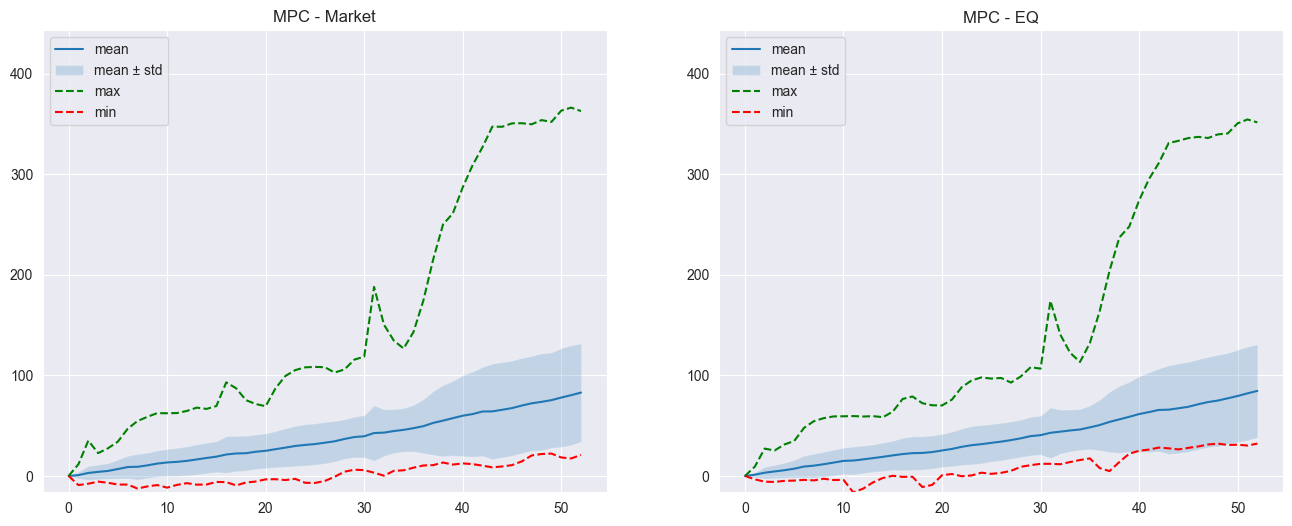

In [510]:
plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'])

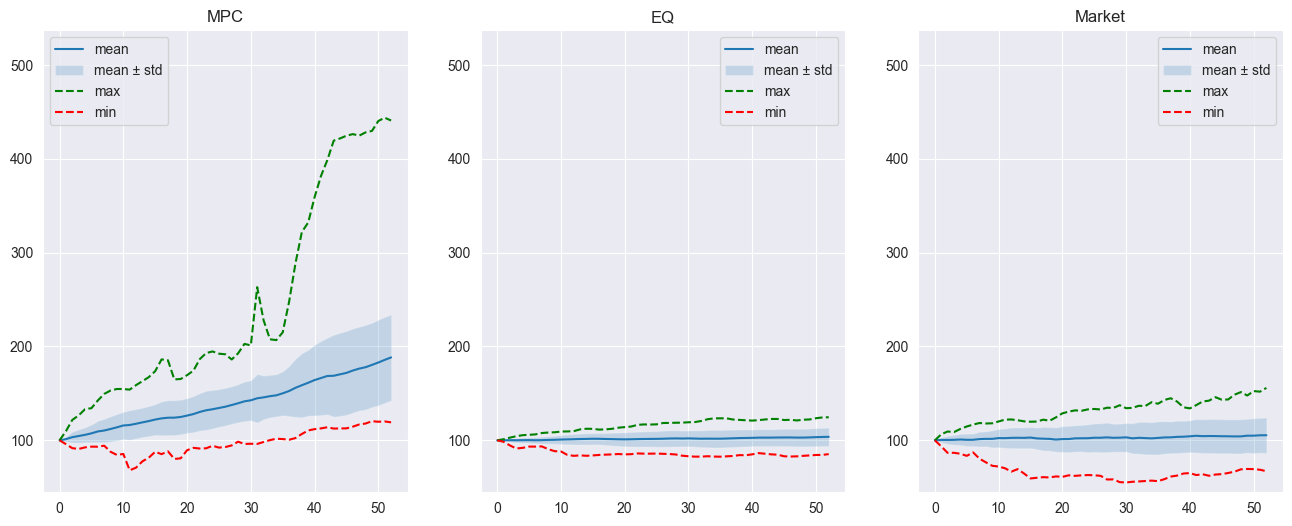

In [511]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [512]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [513]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

mpc_capm = []
eq_capm = []

for col in returns['MPC'].columns:
    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(returns['Market'][col])).fit()
    mpc_capm.append(lm)

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(returns['Market'][col])).fit()
    eq_capm.append(lm)

In [514]:
capm_coeffs = pd.DataFrame(index=['MPC alpha', 'MPC beta', 'EQ alpha', 'EQ beta'])

for i in range(n_simulations):
    capm_coeffs[i] = np.hstack([mpc_capm[i].params.values, eq_capm[i].params.values])

In [515]:
from src.portfolio_analysis import conf_int_high, conf_int_low, conf_int_p

In [516]:
capm_summary = capm_coeffs.agg(['mean', 'std', 'sem', conf_int_low, conf_int_high, conf_int_p], axis=1)
capm_summary # NOTE: betas are with mean (2 sided), alphas with 0 (greater) (so betas p are not very meaningful)

,mean,std,sem,conf_int_low,conf_int_high,conf_int_p
MPC alpha,0.012371,0.004265,0.000603,0.011359,inf,0.000000
MPC beta,0.192607,0.240092,0.033954,0.124374,0.260840,1.000000
EQ alpha,0.000570,0.001414,0.000200,0.000235,inf,0.003194
EQ beta,0.168157,0.061907,0.008755,0.150564,0.185751,1.000000


In [517]:
metrics = compute_metrics(returns, rf)
metrics

,MPC,EQ,Market
mean of mean returns,0.012285,0.000666,0.001076
std of mean returns,0.004200,0.001806,0.003436
se of mean returns,0.000594,0.000255,0.000486
ci_low of mean returns,0.011091,0.000153,0.000100
ci high of mean returns,0.013478,0.001179,0.002053
mean of sharpe ratios,0.466569,0.091657,0.046782
std of sharpe ratios,0.148144,0.231233,0.130847
se of sharpe ratios,0.020951,0.032701,0.018505
ci_low of sharpe ratios,0.424467,0.025941,0.009596
ci high of sharpe ratios,0.508671,0.157373,0.083968
